In [88]:
from B3DB import B3DB_DATA_DICT
import numpy as np 

data = B3DB_DATA_DICT['B3DB_classification']
# drop irrelevant columns
drop_col = ['threshold', 'comments','group', 'CID', 'NO.', 'compound_name', 'IUPAC_name', 'Inchi',
           'reference']
df = data.drop(labels=drop_col, axis=1)
print(df.columns)
print(df.isnull().sum(), '\n')

# drop all na rows in logBB
df = df.dropna(subset=['logBB'])
print(df.isna().sum())


Index(['SMILES', 'logBB', 'BBB+/BBB-'], dtype='object')
SMILES          0
logBB        6749
BBB+/BBB-       0
dtype: int64 

SMILES       0
logBB        0
BBB+/BBB-    0
dtype: int64


In [89]:
from rdkit import Chem
# validate each SMILES string in the dataframe column without sanitization

df['molecule'] = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
print("Occurences of invalid molecules: ", df['molecule'].isna().sum())

Occurences of invalid molecules:  0


In [90]:
# create a canonical smile representation of each molecule to sort a molecule according to predefined logic
# read smiles representation to mol and then from mol to smiles again

df['canon_smiles'] = df['molecule'].apply(lambda mol: Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
)

# check for duplicated canon_smiles and drop
print("Duplicated smile strings: ", df.duplicated().sum())

# replace original molecule column with canonical smile representation format 
df['molecule'] = df['canon_smiles'].apply(lambda x: Chem.MolFromSmiles(x))

Duplicated smile strings:  0


In [91]:
# get accurate total of the number of atoms in each smiles distribution

df['mol_size'] = df['molecule'].apply(lambda x: x.GetNumAtoms())

print(df['mol_size'])

0       28
1       36
2       13
3       19
4       33
        ..
1053    19
1054    20
1055    20
1056    17
1057    18
Name: mol_size, Length: 1058, dtype: int64


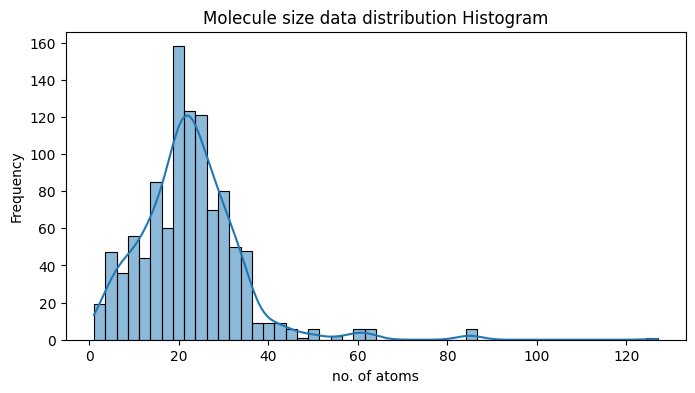

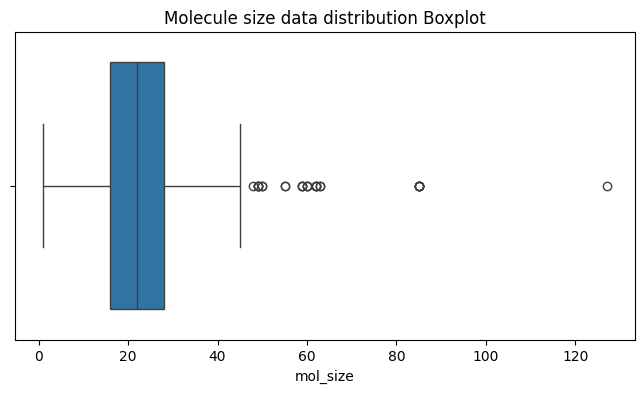

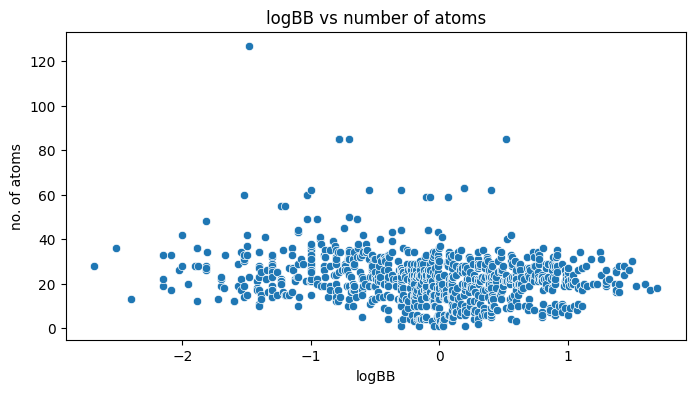

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['mol_size'], bins=50, kde=True)
plt.title('Molecule size data distribution Histogram')
plt.xlabel('no. of atoms')
plt.ylabel('Frequency')

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['mol_size'])
plt.title('Molecule size data distribution Boxplot')


plt.figure(figsize=(8, 4))
g = sns.scatterplot(data=df, x='logBB', y='mol_size')
plt.title('logBB vs number of atoms')
plt.xlabel('logBB')
plt.ylabel('no. of atoms')

plt.show()


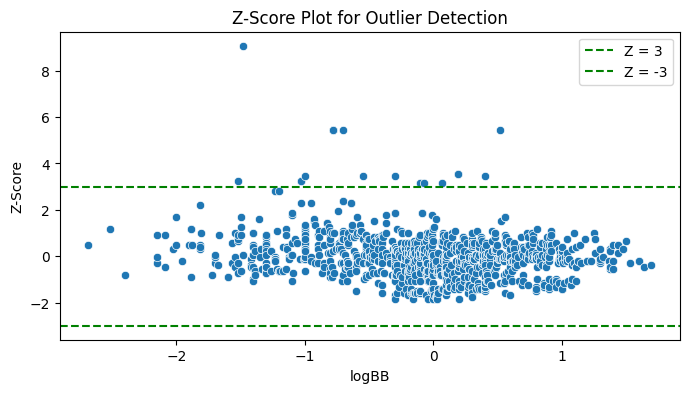

In [93]:
from scipy.stats import zscore

# plot logBB vs mol_size with Z-score analysis with a threshold greater than or less than 3,-3

plt.figure(figsize=(8, 4))
df['Z-score'] = zscore(df['mol_size'])
outliers = df[np.abs(df['Z-score']) > 3]
sns.scatterplot(data=df, x='logBB', y='Z-score')
plt.title('molecular size Z-score analysis')
plt.axhline(y=3, color='g', linestyle='--', label='Z = 3')
plt.axhline(y=-3, color='g', linestyle='--', label='Z = -3')
plt.title('Z-Score Plot for Outlier Detection')
plt.xlabel('logBB')
plt.ylabel('Z-Score')
plt.legend()

plt.show()

In [94]:
from rdkit.Chem import AllChem

def morgan_fp(mol):
    # generate morgan fingerprints with radus 2 and fingerprint size 512
   morgan = AllChem.GetMorganGenerator(radius=2, fpSize=1024)
   return morgan.GetFingerprintAsNumPy(mol)

df['fp'] = df['molecule'].apply(morgan_fp)
print(df.head())


                                              SMILES  logBB BBB+/BBB-  \
0   O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O  -2.69      BBB-   
1  COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...  -2.52      BBB-   
2                             Oc1c(I)cc(Cl)c2cccnc12  -2.40      BBB-   
3                         CCNC(=NCCSCc1ncccc1Br)NC#N  -2.15      BBB-   
4  CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...  -2.15      BBB-   

                                        molecule  \
0  <rdkit.Chem.rdchem.Mol object at 0x176e795b0>   
1  <rdkit.Chem.rdchem.Mol object at 0x176e79310>   
2  <rdkit.Chem.rdchem.Mol object at 0x176e7bb50>   
3  <rdkit.Chem.rdchem.Mol object at 0x176e7bbc0>   
4  <rdkit.Chem.rdchem.Mol object at 0x176e7bc30>   

                                        canon_smiles  mol_size   Z-score  \
0   O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O        28  0.486036   
1  COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...        36  1.180233   
2                   

In [95]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
import rdkit 

# Constitutional Molecular Descriptors

# calculate molecular weight
df['mol_weight'] = df['molecule'].apply(lambda x: Descriptors.MolWt(x))

def getHydrogenCount(mol):
    mol_withH = Chem.AddHs(mol)
    mol_true_count = mol_withH.GetNumAtoms()
    return mol_true_count - mol.GetNumAtoms()
    
# number of hydrogen atoms
df['hydrogen_count'] = df['molecule'].apply(getHydrogenCount)

# number of rotatable bonds
df['rotatable_bonds_count'] = df['molecule'].apply(lambda mol: Descriptors.NumRotatableBonds(mol))


# Physiochemical Properties

# LogP - Lipophilicity calculation
df['logP'] = df['molecule'].apply(lambda mol: Crippen.MolLogP(mol))

# calculate PSA (Polar surface area

df['PSA'] = df['molecule'].apply(lambda mol: Descriptors.TPSA(mol))

# calculate heavy atom count
df['heavy_atom_count'] = df['molecule'].apply(lambda mol: mol.GetNumHeavyAtoms())

# calculate the number of hydrogen bond donors and acceptors
df['num_hbd'] = df['molecule'].apply(lambda mol: rdMolDescriptors.CalcNumHBD(mol))
df['num_hba'] = df['molecule'].apply(lambda mol: rdMolDescriptors.CalcNumHBA(mol))

# calculate molecular refractability
df['mol_ref'] = df['molecule'].apply(lambda mol: Crippen.MolMR(mol))


In [96]:
# map class labels +BBB and -BBB to numerical format
class_mapping = {
    'BBB+' : 1,
    'BBB-' : 0
}
df['BBB+/BBB-'] = df['BBB+/BBB-'].map(class_mapping)

# drop Z-score column before training model
df = df.drop(labels=['Z-score'], axis=1)

In [97]:
# split dataset into X and y
y = df.loc[:, 'BBB+/BBB-']
df = df.drop(labels=['SMILES', 'canon_smiles', 'molecule'], axis=1)
X = df.iloc[:, df.columns != 'BBB+/BBB-']

In [98]:
# set a consistent randomization seed for reproducibility
seed = 42

In [99]:
from sklearn.preprocessing import StandardScaler
import pandas as pd 

sc = StandardScaler()
X_num = X.iloc[:, X.columns != 'fp']
X_std_df = pd.DataFrame(sc.fit_transform(X_num), columns=X_num.columns)

# unpack fp array and assign each bit to a new column
fp_df = pd.DataFrame(X['fp'].tolist())

# combine columns horizontally side-by-side
X_final_df = pd.concat([X_std_df, fp_df], axis=1)

# convert to array for your ML model
X_std = X_final_df.values

In [100]:

from sklearn.model_selection import train_test_split

# split dataset into training and test data sets
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.30, random_state=seed, stratify=y)

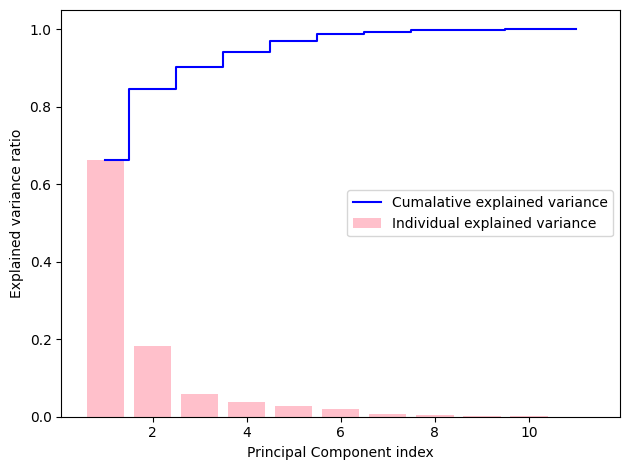

In [101]:
from sklearn.decomposition import PCA

# Dimensionality reduction of non-binary matrix features
X_non_morgan = pd.DataFrame(data=X_train)
X_non_morgan_train =  X_non_morgan.iloc[:, :11]

pca = PCA(n_components=None)
X_non_morgan_pca = pca.fit_transform(X_non_morgan_train)

PC_num = np.arange(pca.n_components_) + 1


# plot pca component explained variance ratios
plt.bar(PC_num, pca.explained_variance_ratio_, align='center', label='Individual explained variance', color='pink')
plt.step(PC_num, np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumalative explained variance', color='blue')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal Component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

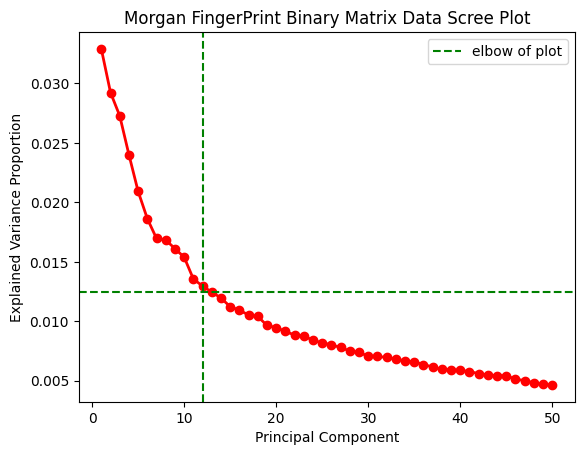

In [102]:
from sklearn.decomposition import TruncatedSVD

# Dimensionality reduction of sparse binary matrix data
X_morgan = pd.DataFrame(data=X_train)
X_morgan = X_morgan.iloc[:, 11:]

svd = TruncatedSVD(n_components=50)
X_morgan_train_svd = svd.fit_transform(X_morgan) 

# screeplot is easier to see the proportion of PCs with the most information with high dim data
plt.plot(np.arange(1,51), svd.explained_variance_ratio_, 'ro-', linewidth=2)
plt.axvline(x=12, color='g', linestyle='--', label='elbow of plot')
plt.axhline(y=0.0125, color='g', linestyle='--')
plt.title('Morgan FingerPrint Binary Matrix Data Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Proportion')
plt.legend()
plt.show()


In [103]:
X_morgan_test_df = pd.DataFrame(data=X_test)
X_morgan_test = X_morgan_test_df.iloc[:, 11:]

X_non_morgan_test_df = pd.DataFrame(data=X_test)
X_non_morgan_test = X_non_morgan_test_df.iloc[:, :11]

# transform non-binary matrix data for pca and pick PC1 and PC2 
pca = PCA(n_components=2)

X_non_morgan_train_pca = pca.fit_transform(X_non_morgan_train)
X_non_morgan_test_pca = pca.transform(X_non_morgan_test)

# transform binary matrix data for svd pick the first 12 PCs
svd = TruncatedSVD(n_components=12)
X_morgan_train_svd = svd.fit_transform(X_morgan) 
X_morgan_test_svd = svd.transform(X_morgan_test) 

# combine both transformed data together
X_train = np.hstack((X_non_morgan_train_pca, X_morgan_train_svd))
X_test = np.hstack((X_non_morgan_test_pca, X_morgan_test_svd))

In [104]:
import scipy.stats

param_range = scipy.stats.loguniform(0.1, 5)

# choose a random seed
np.random.seed(seed)

# sample random hyperparameter config from distribution
param_range.rvs(50)

array([0.43284502, 4.12320653, 1.75241011, 1.04016637, 0.18410729,
       0.18408992, 0.12551115, 2.96215166, 1.05021054, 1.59585736,
       0.10838581, 4.44475417, 2.59594255, 0.22948684, 0.20366442,
       0.2049268 , 0.32877474, 0.77901431, 0.54182823, 0.31245651,
       1.09526627, 0.17258215, 0.31357757, 0.41921594, 0.59545538,
       2.15769675, 0.21839353, 0.7475993 , 1.0150667 , 0.11992725,
       1.07696225, 0.19485671, 0.1289795 , 4.09381361, 4.37099047,
       2.36288642, 0.32925294, 0.14653521, 1.45375556, 0.55950746,
       0.16119045, 0.69389014, 0.11439975, 3.5067765 , 0.27520697,
       1.33538191, 0.33852268, 0.76485651, 0.84887622, 0.20609249])

In [105]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

# make SVC pipeline
pipe_svc = make_pipeline(SVC(random_state=seed))

# define models with config
param_grid = [
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['rbf']}
]

rs = RandomizedSearchCV(estimator=pipe_svc,
                        param_distributions=param_grid,
                        scoring='accuracy',
                        refit=True,
                        n_iter=30,
                        cv=10,
                        random_state=seed,
                        n_jobs=-1)

rs = rs.fit(X_train, y_train)
print(rs.best_params_)

{'svc__C': 2.595942550311263, 'svc__gamma': 0.22948683681130552, 'svc__kernel': 'rbf'}


In [111]:
# retrain model on best params
svm = SVC(random_state=seed, kernel='rbf', C=rs.best_params_['svc__C']
          , gamma=rs.best_params_['svc__gamma'], class_weight='balanced', probability=True)

svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.595942550311263
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.22948683681130552
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [107]:
from sklearn.model_selection import FixedThresholdClassifier

# predict
y_pred = svm.predict(X_test)
print('Misclassified examples: %d' % (y_test != y_pred).sum()) # tells how many predictions were wrong

# accuracy score
from sklearn.metrics import accuracy_score
print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))

Misclassified examples: 26
Accuracy: 0.918


              precision    recall  f1-score   support

           0       0.70      0.55      0.62        38
           1       0.94      0.97      0.95       280

    accuracy                           0.92       318
   macro avg       0.82      0.76      0.79       318
weighted avg       0.91      0.92      0.91       318



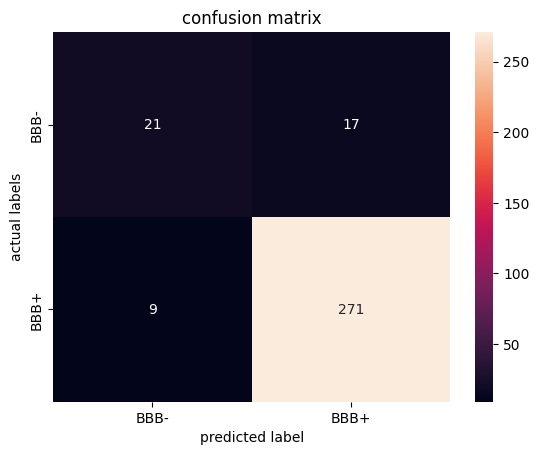

In [108]:
from sklearn.metrics import confusion_matrix as cm, classification_report as cr

# generate performance metrics report
report = cr(y_true=y_test, y_pred=y_pred)
print(report)

# generate confusion matrix
confmat = cm(y_true=y_test, y_pred=y_pred)

sns.heatmap(confmat,
    annot=True,
    fmt='g',
    xticklabels=['BBB-','BBB+'],
    yticklabels=['BBB-','BBB+'])

plt.ylabel('actual labels')
plt.title('confusion matrix')
plt.xlabel('predicted label')
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/var/folders/2j/1q6627rd63n0qq4cxzs4fn6r0000gn/T/ipykernel_17722/17931141.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='r')


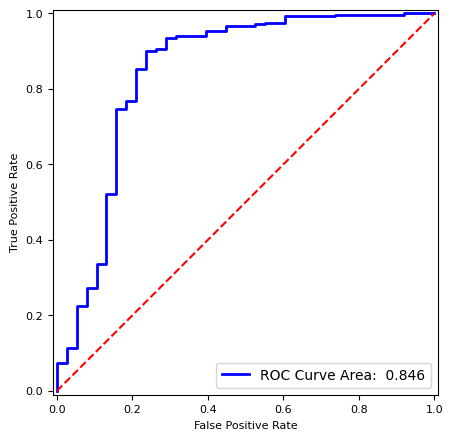

In [117]:
from sklearn.metrics import (
    RocCurveDisplay,
    roc_curve, auc
)

# Get the fpr and tpr of model
svm_proba = svm.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, svm_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve and compare the default threshold to the tuned threshold
fig, ax = plt.subplots(figsize=(5, 5))

disp = RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    name="Kernel RBF SVM",
    color="blue",
    linewidth=2,
    ax=ax,
    label=f'ROC Curve Area: {roc_auc: .3f}'
)

plt.plot([0, 1], [0, 1], 'k--', color='r')

disp.ax_.set_ylabel("True Positive Rate", fontsize=8)
disp.ax_.set_xlabel("False Positive Rate", fontsize=8)
disp.ax_.tick_params(labelsize=8)
plt.show()


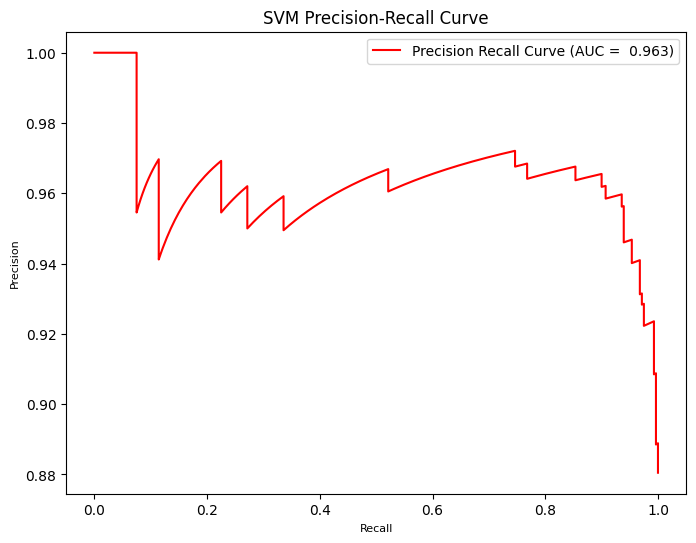

Best f1_score:  0.957
Optimal Threshold index:  17
Optimal Threshold:  0.264


In [131]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, svm_proba)
pr_auc = auc(recall, precision)

# plotting precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision Recall Curve (AUC = {pr_auc: .3f})',
        color='r')
plt.xlabel('Recall', fontsize=8)
plt.ylabel('Precision', fontsize=8)
plt.title('SVM Precision-Recall Curve')
plt.legend()
plt.show()

f1_score = 2 * ((precision * recall)/(precision + recall))
print(f'Best f1_score: {np.max(f1_score) : .3f}')
print(f'Optimal Threshold: {thresholds[np.argmax(f1_score)] : .3f}')